**Exploratory Data Analysis**

Import Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

Dataset Overview

In [ ]:
dataset=pd.read_csv('/content/CLEANED_DATA.csv')
dataset.head()

,brand,model,color,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
0,ford,Kuga,black,2023,190.0,Automatic,Hybrid,5.4,124.0,100.0,38490.0
1,hyundai,i10,black,2018,67.0,Manual,Petrol,4.6,106.0,27782.0,11555.0
2,audi,Q4 e-tron,grey,2021,170.0,Automatic,Electric,5.8,0.0,4247.0,48886.0
3,honda,CR-V,red,2018,155.0,Automatic,Petrol,7.5,175.0,57000.0,24490.0
4,kia,Sportage,black,2023,150.0,Manual,Petrol,5.9,150.0,7500.0,34990.0


In [ ]:
#shape of the dataset
dataset.shape

(98644, 11)

In [ ]:
#check is the dataset have null value
dataset.isnull().sum()

,0
brand,0
model,0
color,0
year,0
power_ps,0
transmission_type,0
fuel_type,0
fuel_consumption_l_100km,0
fuel_consumption_g_km,0
mileage_in_km,0


In [ ]:
#dataset basic information(dtype,non-null values)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98644 entries, 0 to 98643
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   brand                     98644 non-null  object 
 1   model                     98644 non-null  object 
 2   color                     98644 non-null  object 
 3   year                      98644 non-null  int64  
 4   power_ps                  98644 non-null  float64
 5   transmission_type         98644 non-null  object 
 6   fuel_type                 98644 non-null  object 
 7   fuel_consumption_l_100km  98644 non-null  float64
 8   fuel_consumption_g_km     98644 non-null  float64
 9   mileage_in_km             98644 non-null  float64
 10  price_in_euro             98644 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 8.3+ MB


In [ ]:

dataset.describe()

,year,power_ps,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
count,98644.000000,98644.000000,98644.000000,98644.000000,9.864400e+04,9.864400e+04
mean,2016.388011,190.472811,6.182212,145.336929,8.614175e+04,2.900845e+04
std,5.193107,111.274367,1.971452,43.664855,7.934979e+04,4.229476e+04
min,1995.000000,34.000000,0.000000,0.000000,0.000000e+00,1.500000e+02
25%,2014.000000,120.000000,5.100000,124.000000,2.617375e+04,1.289000e+04
50%,2018.000000,159.000000,5.800000,139.000000,6.889550e+04,2.000000e+04
75%,2020.000000,218.000000,6.800000,159.000000,1.280000e+05,3.200000e+04
max,2023.000000,999.000000,19.900000,350.000000,3.800000e+06,2.289000e+06


Dataset from 2015 to 2023

In [ ]:
df=dataset[dataset['year']>=2015]
df.head()

,brand,model,color,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
0,ford,Kuga,black,2023,190.0,Automatic,Hybrid,5.4,124.0,100.0,38490.0
1,hyundai,i10,black,2018,67.0,Manual,Petrol,4.6,106.0,27782.0,11555.0
2,audi,Q4 e-tron,grey,2021,170.0,Automatic,Electric,5.8,0.0,4247.0,48886.0
3,honda,CR-V,red,2018,155.0,Automatic,Petrol,7.5,175.0,57000.0,24490.0
4,kia,Sportage,black,2023,150.0,Manual,Petrol,5.9,150.0,7500.0,34990.0


In [ ]:
df.shape

(70416, 11)

In [ ]:
len(dataset)-len(df)

28228

**Univariant Analysis**

Categorical Features

Unique no category in Categorical Features

In [ ]:
for i in df.columns:
  if df[i].dtype=='object':
    print(f"{i}:{df[i].nunique()}")


brand:28
model:400
color:14
transmission_type:4
fuel_type:11


Brand

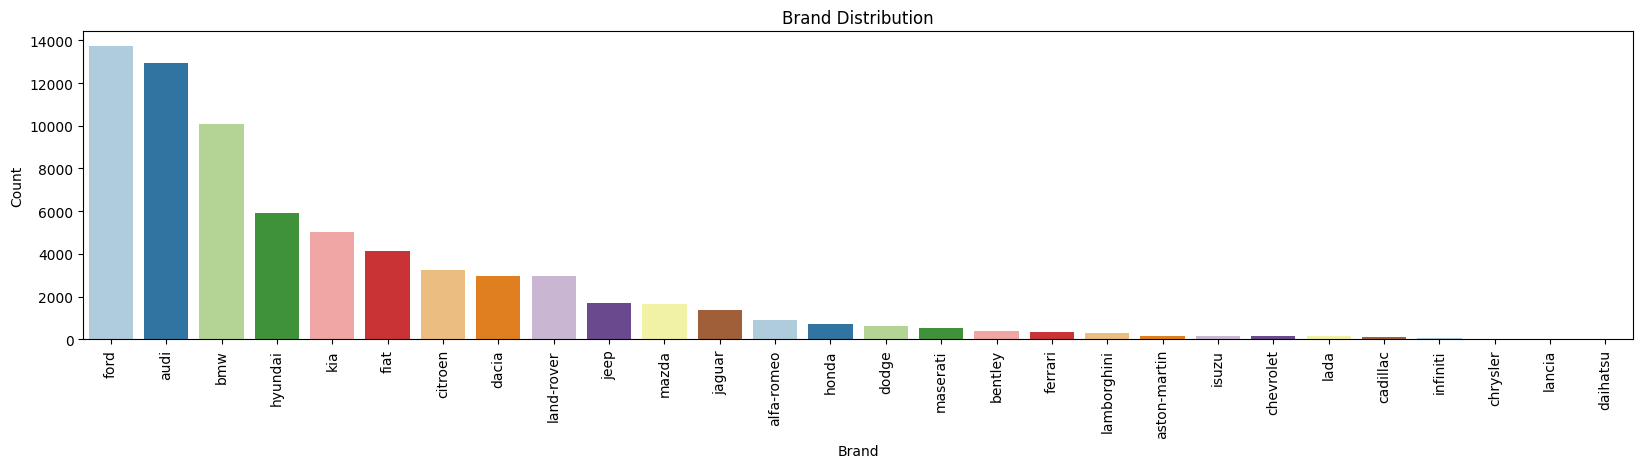

In [ ]:
plt.figure(figsize=(20,4))
sns.countplot(x=df['brand'],palette="Paired",order=df['brand'].value_counts().index)
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.title('Brand Distribution')
plt.show()

In [ ]:
df['brand'].value_counts().head()

,count
brand,
ford,13733
audi,12921
bmw,10093
hyundai,5901
kia,5036


Insight:The highest number of used car listings in the dataset.
1.  Ford
2.  Audi
3.  BMW

Model

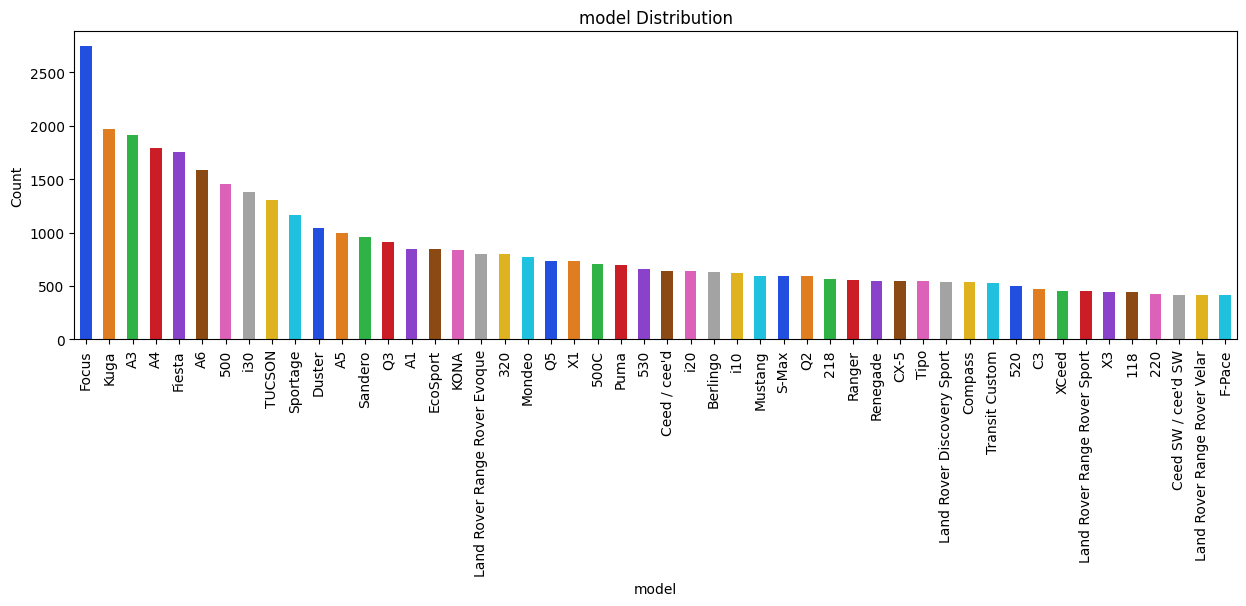

In [ ]:
plt.figure(figsize=(15,4))
sns.countplot(x=df['model'],palette="bright",order=df['model'].value_counts().index[:50],width=0.5)
plt.xlabel('model')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.title('model Distribution')
plt.show()

Insight:The highest number of used car listings in the dataset.
1.  Focus
2.  Kuga
3.  A3

Color

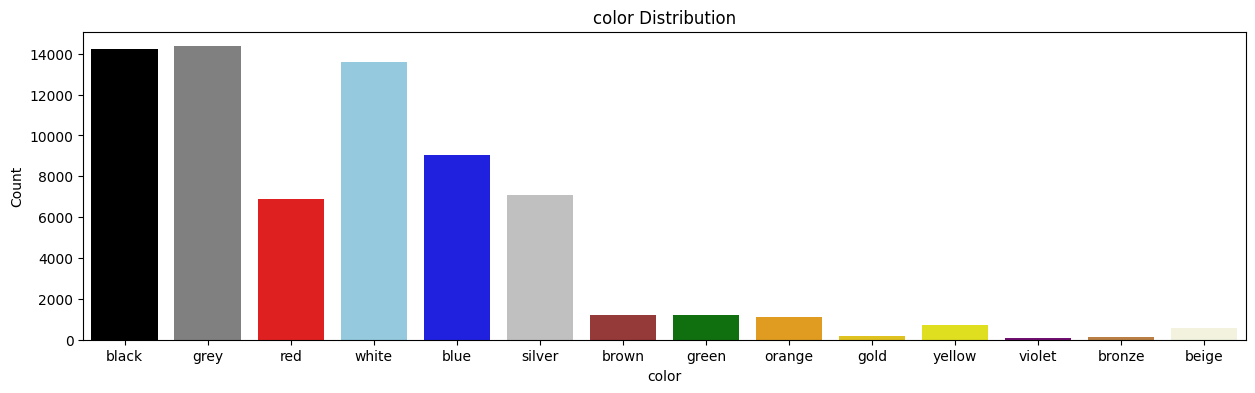

In [ ]:
color={'black':'black', 'grey':'grey', 'red':'red', 'white':'skyblue', 'blue':'blue', 'silver':'silver', 'brown':'brown',
       'green':'green', 'orange':'orange', 'gold':'gold', 'yellow':'yellow', 'violet':'purple', 'bronze':'#CD7F32', 'beige':'beige'}
plt.figure(figsize=(15,4))
sns.countplot(x=df['color'],palette=color)
plt.xlabel('color')
plt.ylabel('Count')
plt.title('color Distribution')
plt.show()

Insight:The highest number of used car listings in the dataset.
1.  grey
2.  Black
3.  white

Transmission Type

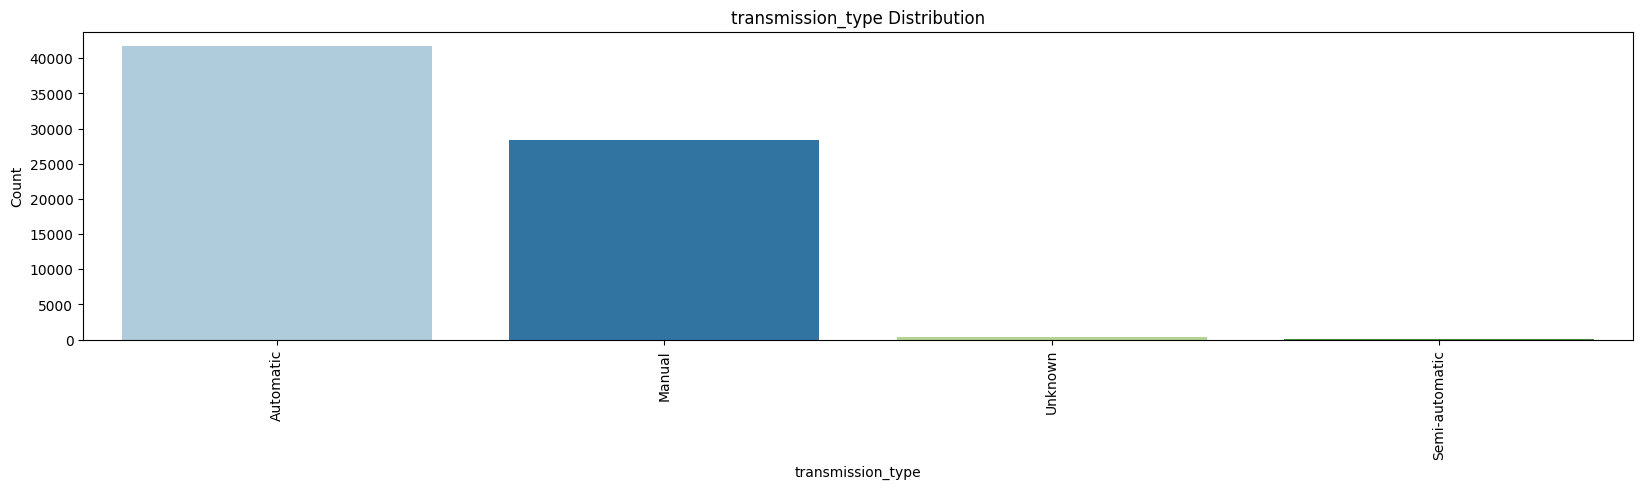

In [ ]:
plt.figure(figsize=(20,4))
sns.countplot(x=df['transmission_type'],palette="Paired")
plt.xlabel('transmission_type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.title('transmission_type Distribution')
plt.show()

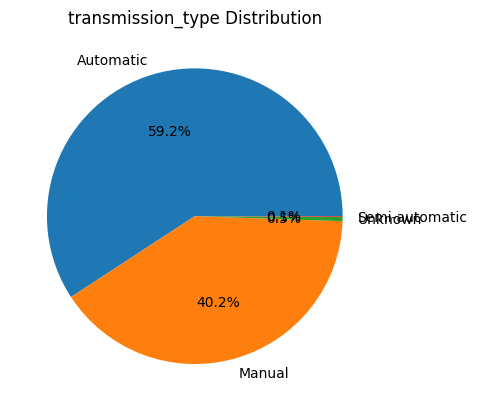

In [ ]:
plt.pie(df['transmission_type'].value_counts(),labels=df['transmission_type'].value_counts().index,autopct='%1.1f%%')
plt.title('transmission_type Distribution')
plt.show()

Insight:
* Around half of the cars are automatic (50%), while manual cars account for 42% of the dataset.

* This indicates that both transmission types are widely used in the German market

Fuel Type

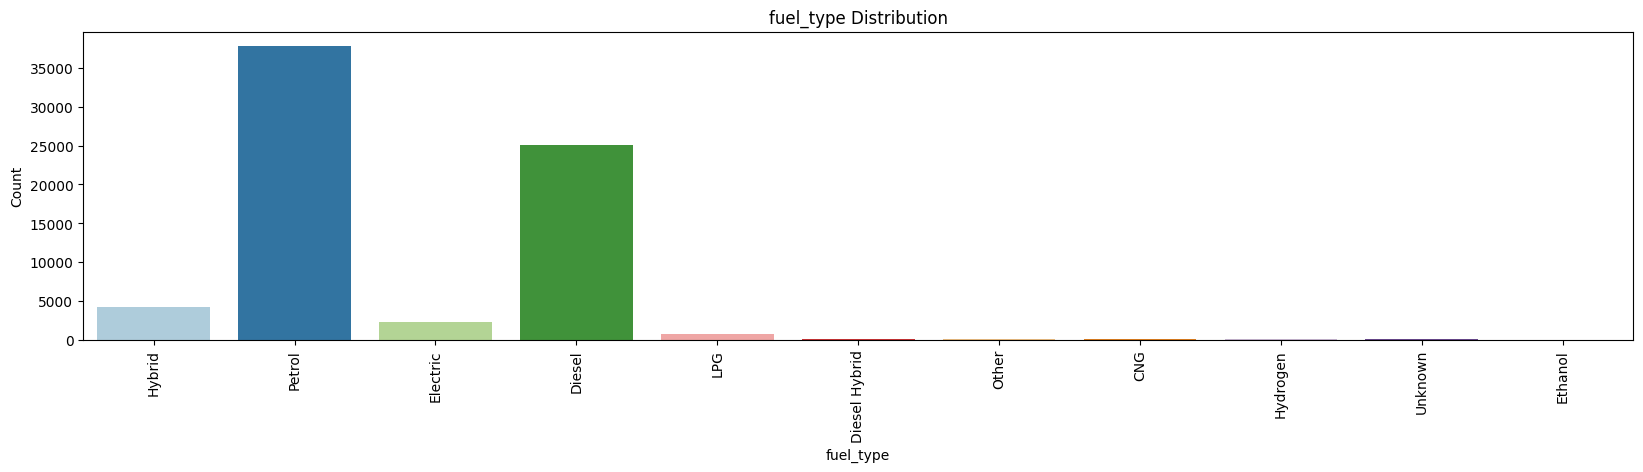

In [ ]:
plt.figure(figsize=(20,4))
sns.countplot(x=df['fuel_type'],palette="Paired")
plt.xlabel('fuel_type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.title('fuel_type Distribution')
plt.show()

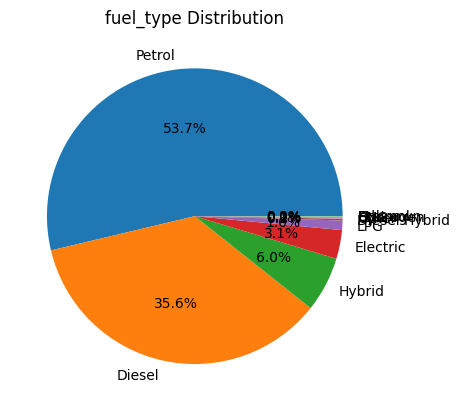

In [ ]:
plt.pie(df['fuel_type'].value_counts(),labels=df['fuel_type'].value_counts().index,autopct='%1.1f%%')
plt.title('fuel_type Distribution')
plt.show()

Insight:
*  Petrol cars dominate the dataset (53.7%), followed by Diesel cars (35.6%).
*  This reflects the traditional fuel preference in the German market

* Other fuel types are very less

Numerical Features

Year

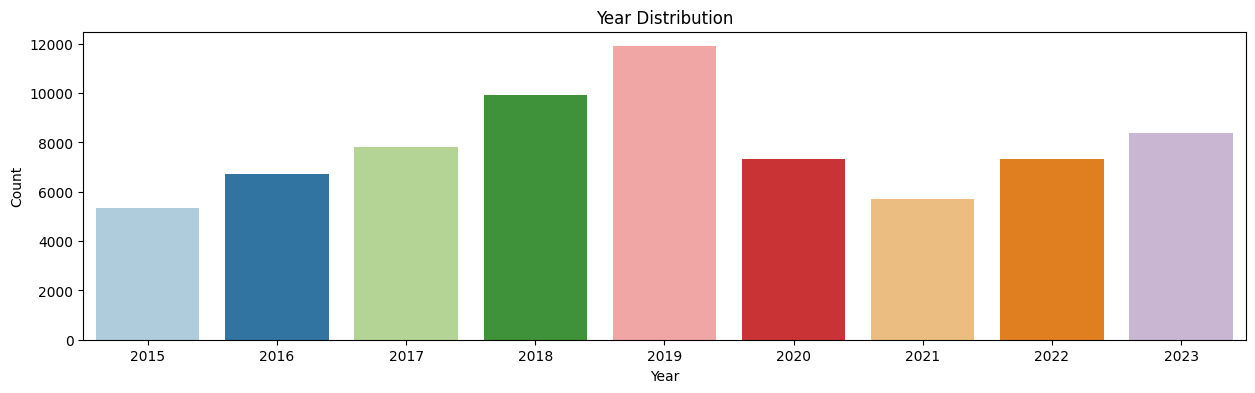

In [ ]:
plt.figure(figsize=(15,4))
sns.countplot(x=df['year'],palette="Paired")
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Year Distribution')
plt.show()

Insight:
* The dataset shows that 2019 and 2018 have the highest number of used car registrations.

* This indicates that relatively newer cars dominate the used car listings

Power in Ps

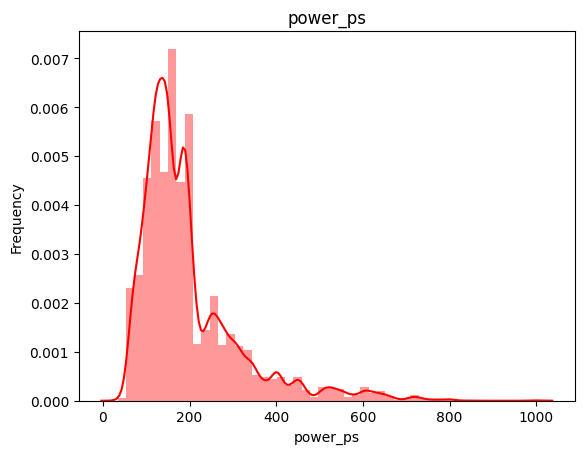

In [ ]:
sns.distplot(df['power_ps'],color='red')
plt.xlabel('power_ps')
plt.ylabel('Frequency')
plt.title('power_ps')
plt.show()#

* The distribution is right-skewed with most cars having power between 50–200 PS.

*  A few vehicles go above 400 PS,representing high-performance or luxury cars.



Fuel Consumption L/*100KM*

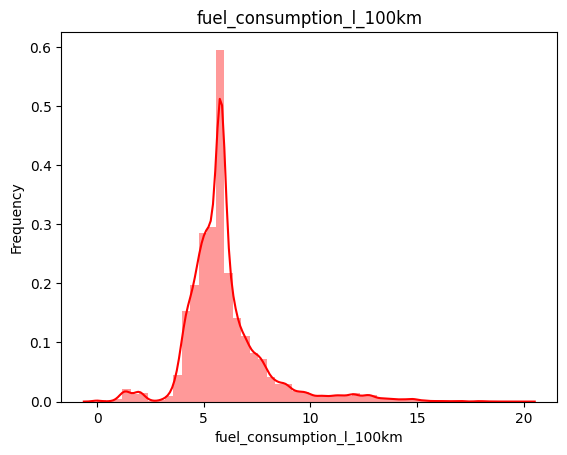

In [ ]:
sns.distplot(df['fuel_consumption_l_100km'],color='red')
plt.xlabel('fuel_consumption_l_100km')
plt.ylabel('Frequency')
plt.title('fuel_consumption_l_100km')
plt.show()

most cars are moderately fuel-efficient (5–8 L/100km)

CO2 Emission

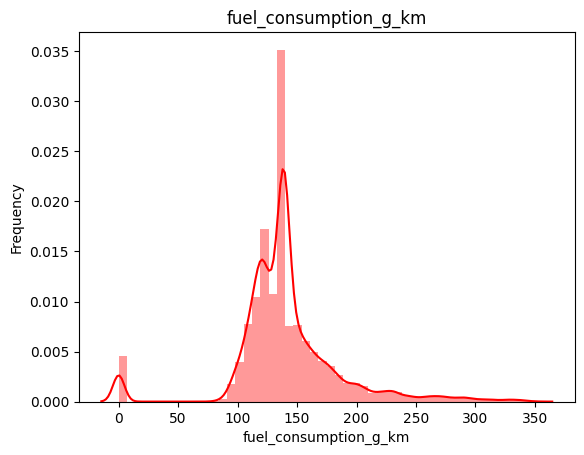

In [ ]:
sns.distplot(df['fuel_consumption_g_km'],color='red')
plt.xlabel('fuel_consumption_g_km')
plt.ylabel('Frequency')
plt.title('fuel_consumption_g_km')
plt.show()#

It is not normal but multimodal and right-skewed.
few are near zero (electric/hybrid)

Mileage

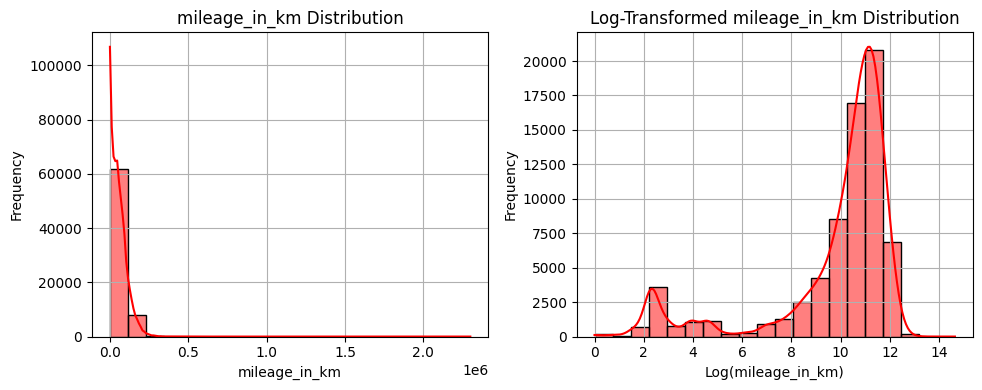

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data=df, x='mileage_in_km', bins=20, color='red', ax=axes[0],kde=True)
axes[0].set_xlabel('mileage_in_km')
axes[0].set_ylabel('Frequency')
axes[0].set_title('mileage_in_km Distribution')
axes[0].grid(True)

sns.histplot(data=df, x=np.log(df['mileage_in_km']), bins=20, color='red', ax=axes[1],kde=True)
axes[1].set_xlabel('Log(mileage_in_km)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed mileage_in_km Distribution')
axes[1].grid(True)

plt.tight_layout()

plt.show()


Insight:
* The original mileage distribution was highly right-skewed, indicating most cars had relatively lower mileage while a few had very high mileage.

* After applying a log transformation, the distribution improved and resembled a binomial/normal-like distribution, making it more suitable for modeling.

* This transformation helps in reducing the effect of extreme values (outliers) and stabilizing variance.

Price in Euro

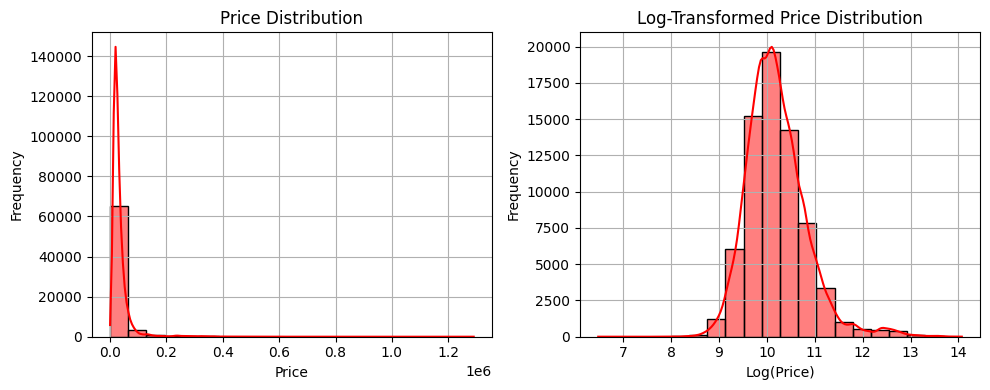

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data=df, x='price_in_euro', bins=20, color='red', ax=axes[0],kde=True)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')
axes[0].grid(True)

sns.histplot(data=df, x=np.log(df['price_in_euro']), bins=20, color='red', ax=axes[1],kde=True)
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].grid(True)

plt.tight_layout()

plt.show()


Insight:
* The original price distribution was highly right-skewed, with most cars priced in the lower range and a few luxury cars priced extremely high.

* After applying a log transformation, the distribution improved and now resembles a normal distribution.

* This transformation reduces the influence of very high-priced outliers and makes the feature more suitable for modeling.

**Bivariant Analysis**

Categorical features

Brand

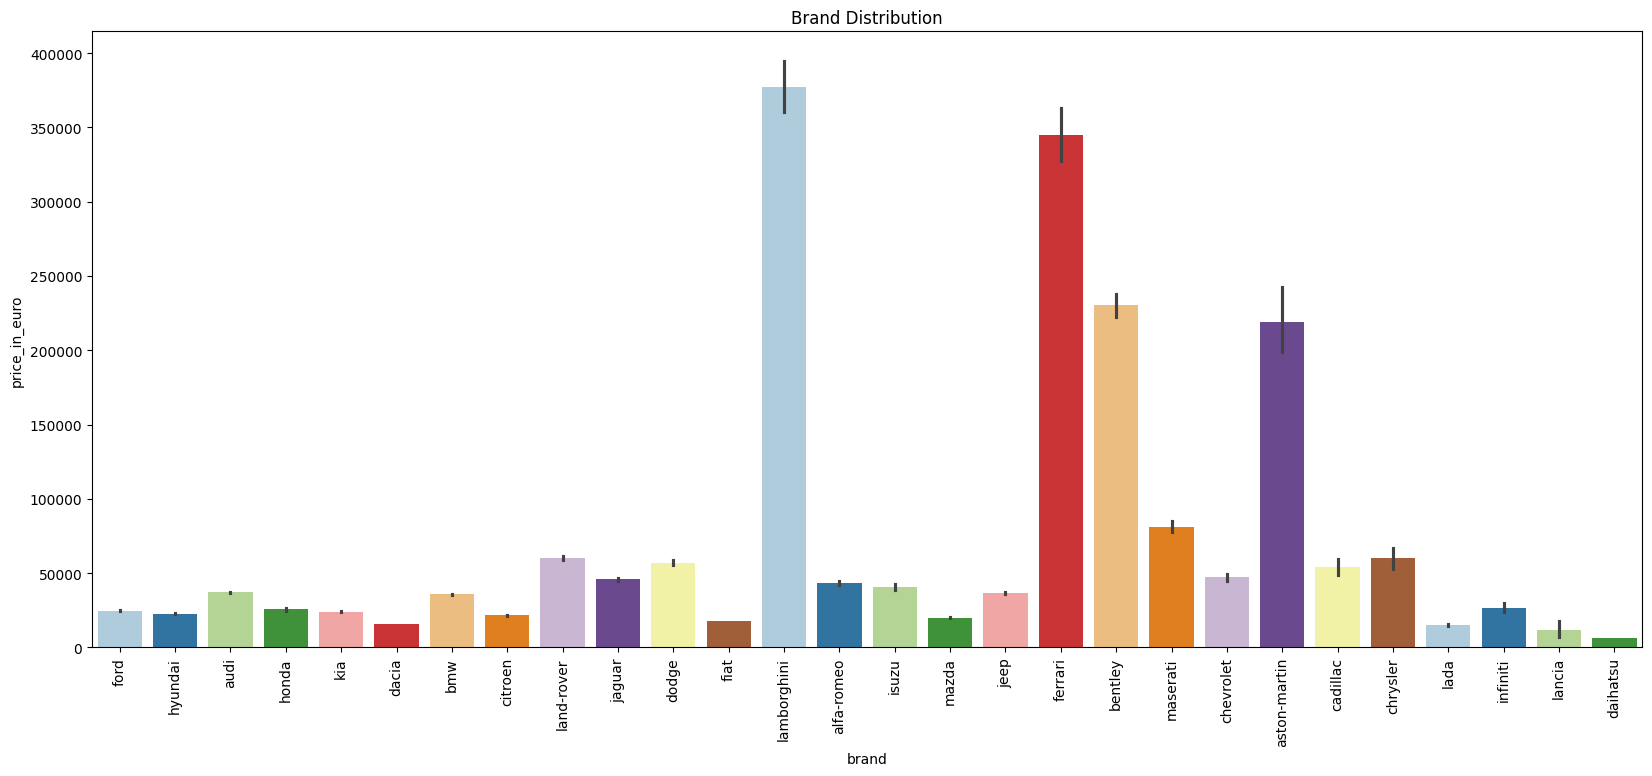

In [ ]:
plt.figure(figsize=(20,8))
plt.title('Brand Distribution')
sns.barplot(x=df['brand'],y=df['price_in_euro'],palette='Paired')
plt.xticks(rotation=90)
plt.show()

Based on average car prices, the top 5 most expensive brands in the dataset are:

1. Lamborghini

2. Ferrari

3. Bentley

4. Aston Martin

5. Maserati

These luxury/exotic brands have significantly higher prices compared to mainstream brands.

Model

In [ ]:
high=df.sort_values(by='price_in_euro', ascending=False)[['price_in_euro','model','brand']].head(300)
high.head(10)

,price_in_euro,model,brand
41963,1290000.0,F12,ferrari
29570,1288000.0,Aston Martin Vantage,aston-martin
92908,1170000.0,Aston Martin Vantage,aston-martin
53356,1045800.0,458,ferrari
68067,1010101.0,550,bmw
84431,1000000.0,Aventador,lamborghini
19766,989812.0,812,ferrari
36778,977000.0,Aventador,lamborghini
30967,959980.0,488,ferrari
69907,865000.0,812,ferrari


Top models

In [ ]:
high['model'].value_counts().head()

,count
model,
Aventador,73
812,40
488,37
Huracan,30
Urus,30


Among the top 300 most expensive cars, models like the
Aventador (73)
812 (40),
488 (37),
Huracan (30), and
Urus (30) are the most frequent high-priced cars.

Color


<Axes: title={'center': 'Color Distribution'}, xlabel='color', ylabel='price_in_euro'>

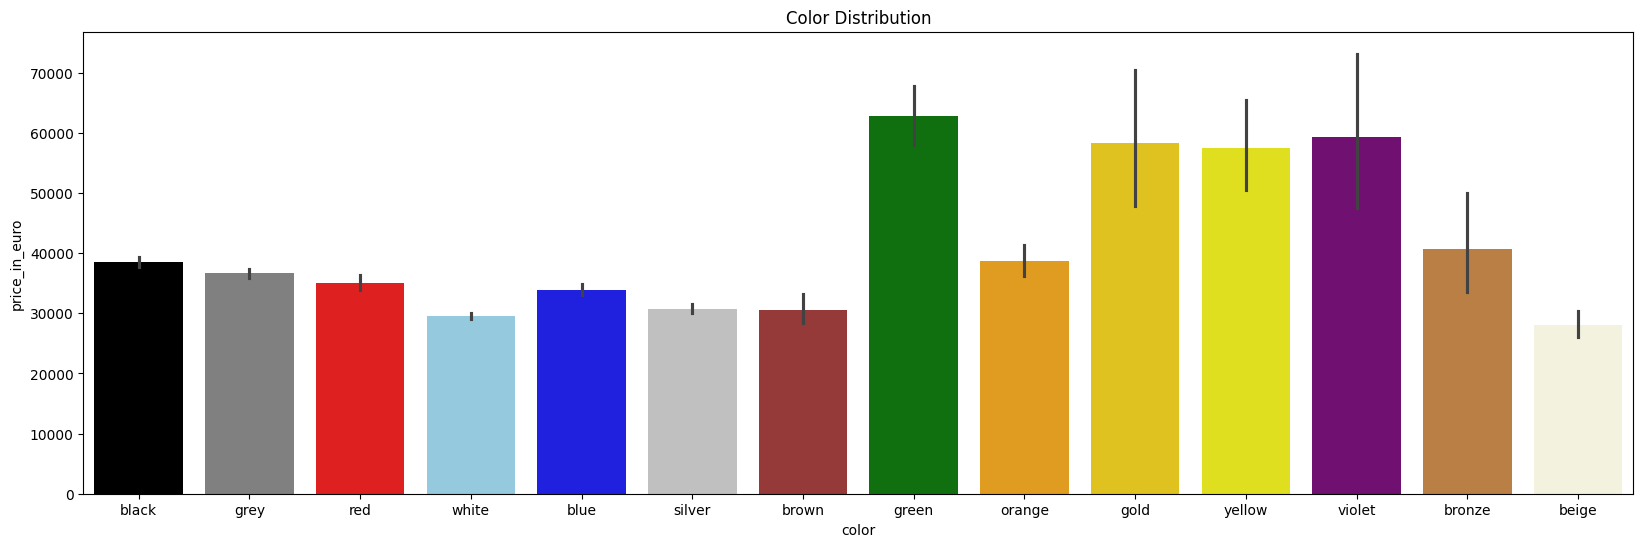

In [ ]:
color={'black':'black', 'grey':'grey', 'red':'red', 'white':'skyblue', 'blue':'blue', 'silver':'silver', 'brown':'brown',
       'green':'green', 'orange':'orange', 'gold':'gold', 'yellow':'yellow', 'violet':'purple', 'bronze':'#CD7F32', 'beige':'beige'}
plt.figure(figsize=(20,6))
plt.title('Color Distribution')
sns.barplot(x=df['color'],y=df['price_in_euro'],palette=color)

Based on average car prices, the top 5 most expensive car colors in the dataset are:

1. Green

2. Violet

3. gold

4. yellow

5. bronze

Transmission Type

In [ ]:
df['transmission_type'].value_counts()

,count
transmission_type,
Automatic,41691
Manual,28340
Unknown,320
Semi-automatic,65


Insight :
Automatic and Manual cars make up the majority of listings in the dataset.






semi automatic information

In [ ]:
df[df['transmission_type']=='Semi-automatic'].sort_values(by='price_in_euro',ascending=False)['brand'].value_counts()

,count
brand,
ford,19
ferrari,10
dacia,10
fiat,9
bmw,5
audi,5
citroen,2
lamborghini,1
bentley,1


Insight:
* The dataset shows that Semi-automatic cars are very rare, with only 65
listings.

* Among them, there are 10 Ferraris, 1 Lamborghini, and 1 Bentley, indicating that this transmission type is often associated with luxury and supercars.

In [ ]:
df[df['transmission_type']=='Semi-automatic'].sort_values(by='price_in_euro',ascending=False).describe()

,year,power_ps,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,2017.338462,250.923077,6.138462,140.169231,68564.507692,86843.338462
std,1.670301,224.959045,2.527393,39.285640,58431.213899,168535.876221
min,2015.000000,67.000000,3.800000,95.000000,168.000000,8000.000000
25%,2016.000000,90.000000,5.000000,120.000000,21500.000000,13499.000000
50%,2017.000000,170.000000,5.300000,138.000000,61650.000000,17590.000000
75%,2018.000000,313.000000,5.800000,139.000000,102517.000000,35900.000000
max,2023.000000,751.000000,16.000000,289.000000,231000.000000,749900.000000


In [ ]:
df[df['transmission_type']=='Unknown'].sort_values(by='price_in_euro',ascending=False)['brand'].value_counts()

,count
brand,
ford,102
bmw,39
hyundai,36
audi,25
land-rover,18
kia,17
fiat,14
ferrari,12
alfa-romeo,10


Insight:

* The Unknown transmission category is very small, but it contains few high-value supercars


* there are 12 Ferraris and 4 Lamborghinis in this group.

In [ ]:
df[df['transmission_type']=='Unknown'].sort_values(by='price_in_euro',ascending=False).describe()

,year,power_ps,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,2018.768750,217.159375,5.745937,127.303125,60488.793750,46318.296875
std,2.179189,161.387566,1.906493,55.973393,50033.320946,84781.196069
min,2015.000000,45.000000,0.000000,0.000000,6.000000,6300.000000
25%,2017.000000,120.000000,4.900000,109.750000,22355.000000,16575.000000
50%,2019.000000,150.000000,5.800000,135.500000,52000.500000,24449.500000
75%,2020.000000,227.500000,5.800000,139.000000,85200.000000,38612.500000
max,2023.000000,999.000000,18.400000,331.000000,399000.000000,779000.000000


unknown type information

Fuel Type

In [ ]:
df[df['fuel_type']=='Petrol'].sort_values(by='price_in_euro',ascending=False).describe()

,year,power_ps,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
count,37826.000000,37826.000000,37826.000000,37826.000000,3.782600e+04,3.782600e+04
mean,2019.215619,198.014117,6.494815,149.768598,4.244918e+04,3.687069e+04
std,2.385135,142.051649,2.072912,43.426226,3.825457e+04,5.751741e+04
min,2015.000000,57.000000,0.000000,95.000000,0.000000e+00,6.500000e+02
25%,2017.000000,110.000000,5.300000,125.000000,1.190000e+04,1.600000e+04
50%,2019.000000,150.000000,5.800000,139.000000,3.650000e+04,2.255000e+04
75%,2021.000000,230.000000,6.900000,156.000000,6.432875e+04,3.444000e+04
max,2023.000000,999.000000,19.900000,350.000000,2.300000e+06,1.290000e+06


petrol information

In [ ]:
df[df['fuel_type']=='Petrol'].sort_values(by='price_in_euro',ascending=False)

,brand,model,color,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
41963,ferrari,F12,yellow,2017,775.0,Automatic,Petrol,5.8,139.0,10800.0,1290000.0
29570,aston-martin,Aston Martin Vantage,green,2022,700.0,Automatic,Petrol,5.8,139.0,1600.0,1288000.0
92908,aston-martin,Aston Martin Vantage,blue,2022,700.0,Automatic,Petrol,11.4,298.0,80.0,1170000.0
53356,ferrari,458,blue,2015,605.0,Automatic,Petrol,13.3,307.0,2824.0,1045800.0
84431,lamborghini,Aventador,black,2021,770.0,Automatic,Petrol,5.8,139.0,4053.0,1000000.0
...,...,...,...,...,...,...,...,...,...,...,...
65036,lada,Kalina,brown,2017,98.0,Manual,Petrol,6.4,148.0,67301.0,3800.0
92864,ford,Focus,black,2015,125.0,Manual,Petrol,4.7,111.0,89500.0,3200.0
63639,ford,Ka/Ka+,red,2015,69.0,Manual,Petrol,4.9,115.0,150000.0,2600.0
68585,ford,Fiesta,silver,2016,60.0,Manual,Petrol,5.2,144.0,125500.0,2200.0


Numerical features

Year

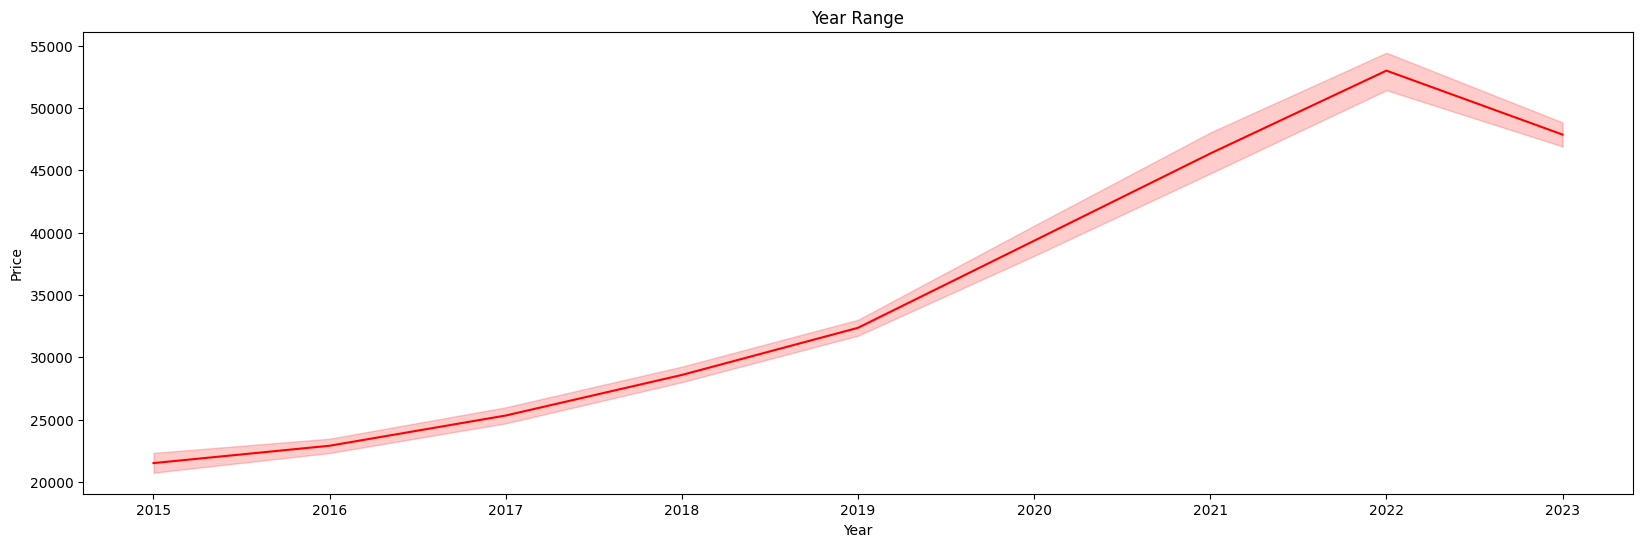

In [ ]:
plt.figure(figsize=(20,6))
sns.lineplot(x=df['year'],y=df['price_in_euro'],color='red')
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Year Range')
plt.show()

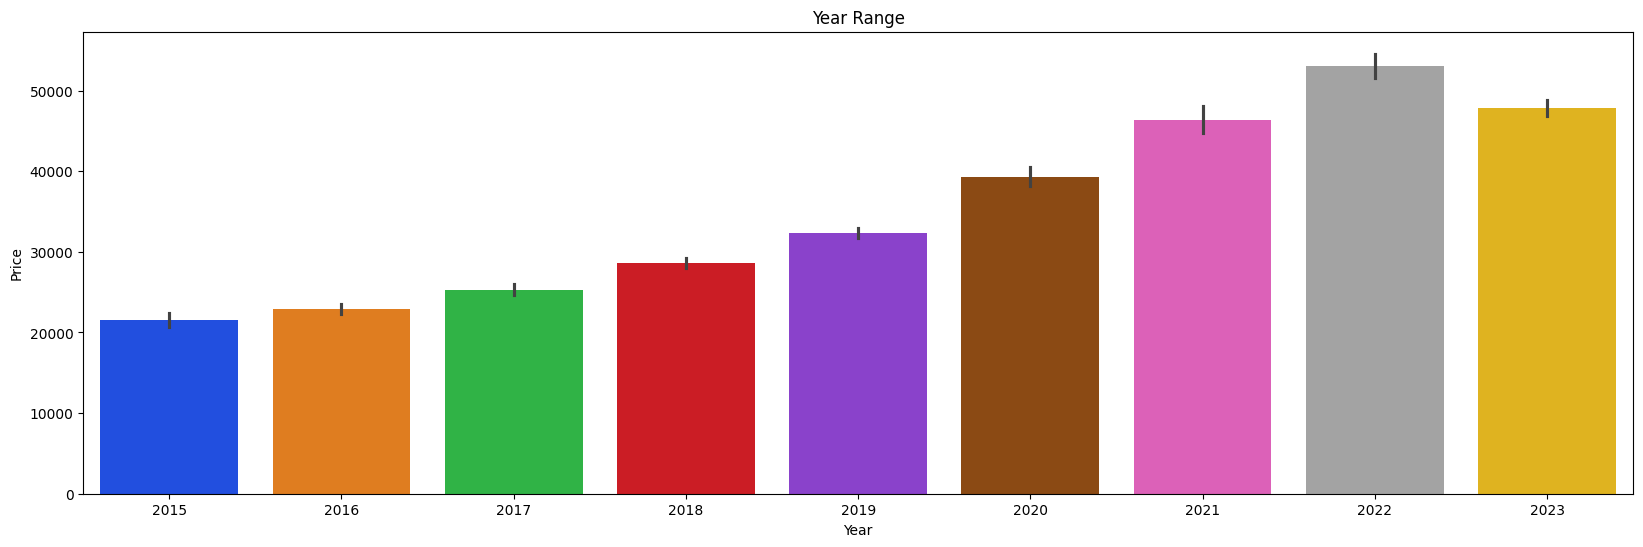

In [ ]:
plt.figure(figsize=(20,6))
plt.title('Year Range')

sns.barplot(x=df['year'],y=df['price_in_euro'],palette="bright")
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

Insight:
Cars registered in 2021–2023 have significantly higher average prices compared to other years, indicating that newer models retain stronger resale value in the German used car market.

Fuel Consumption L/*100KM*

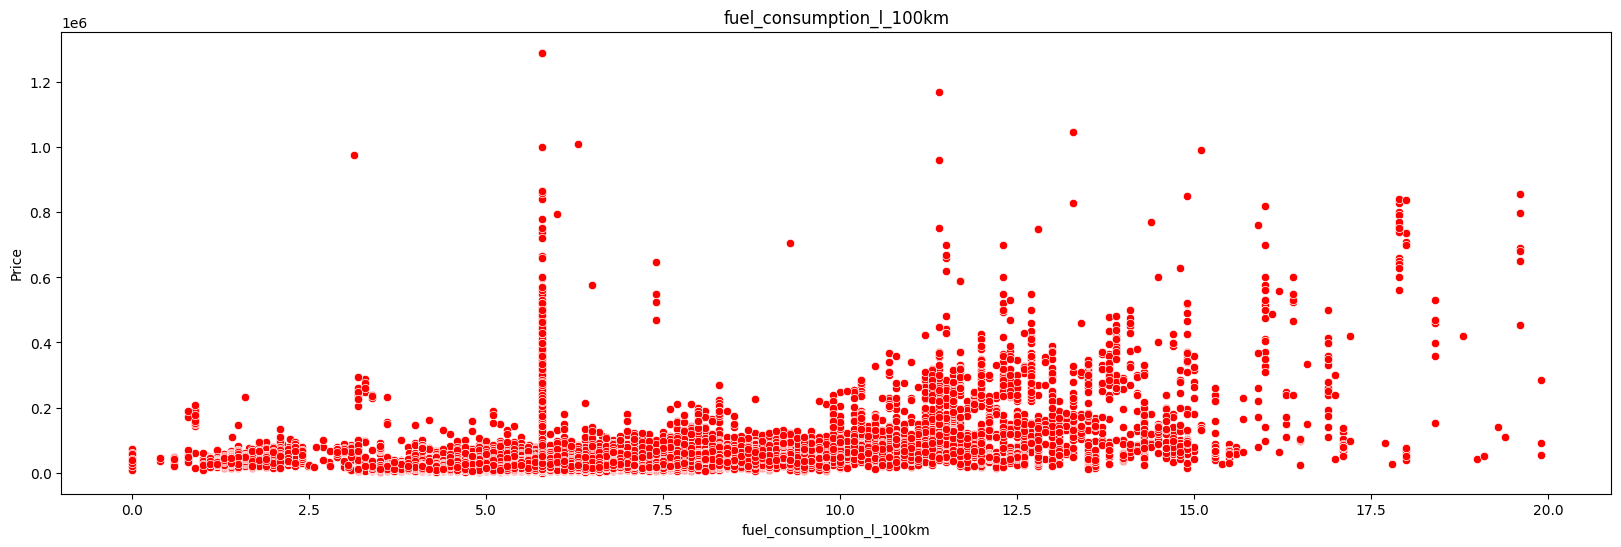

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(x=df['fuel_consumption_l_100km'],y=df['price_in_euro'],color='red')
plt.xlabel('fuel_consumption_l_100km')
plt.ylabel('Price')
plt.title('fuel_consumption_l_100km')
plt.show()

Insight: Fuel consumption does not directly decide the car price. Some low fuel cars are very costly because of brand and features, while some high fuel cars are not costly. Price depends more on brand and power than only fuel consumption.

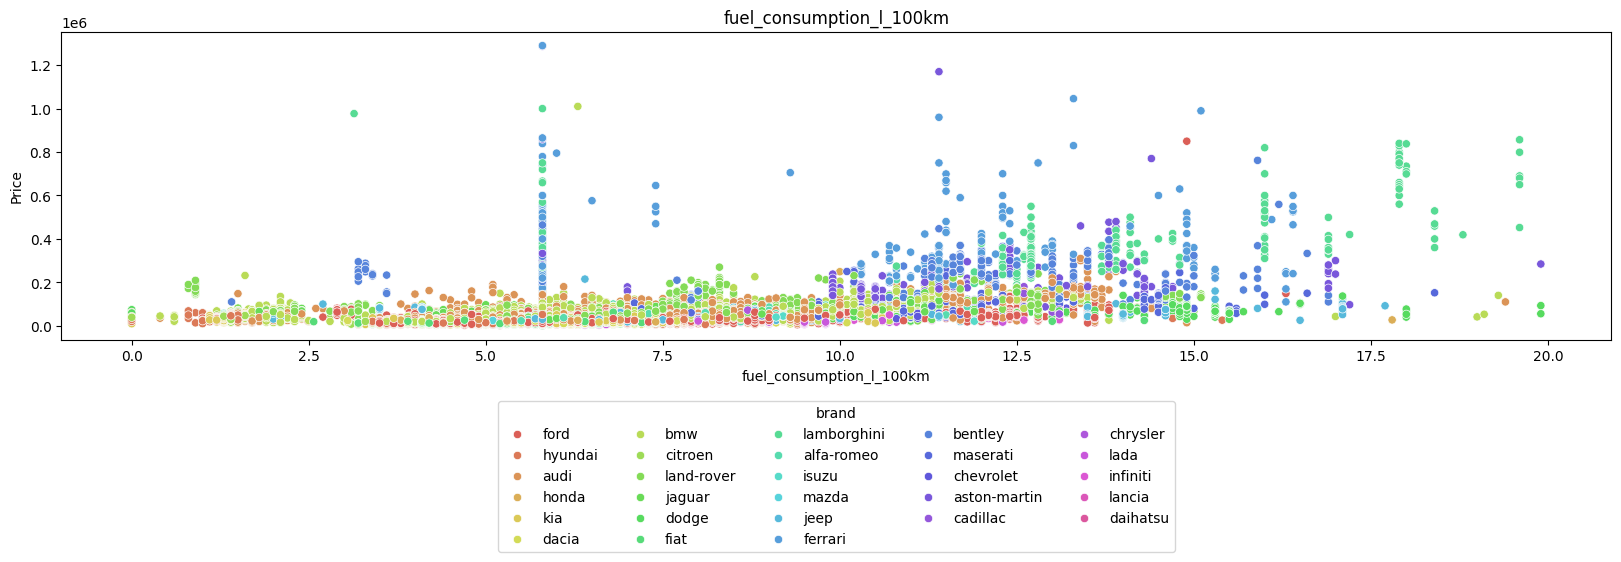

In [ ]:
pal=sns.color_palette("hls",30)
plt.figure(figsize=(20,4))
sns.scatterplot(x=df['fuel_consumption_l_100km'],y=df['price_in_euro'],hue=df['brand'],palette=pal)
plt.xlabel('fuel_consumption_l_100km')
plt.ylabel('Price')
plt.title('fuel_consumption_l_100km')


plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center',ncol=5, borderaxespad=0.,title='brand')
plt.show()

Insight:
*  Most cars are in the low fuel consumption and low-to-mid price range, indicating affordability and efficiency.

*  High-priced, branded cars tend to have higher fuel consumption (L/100 km), reflecting performance-oriented designs.

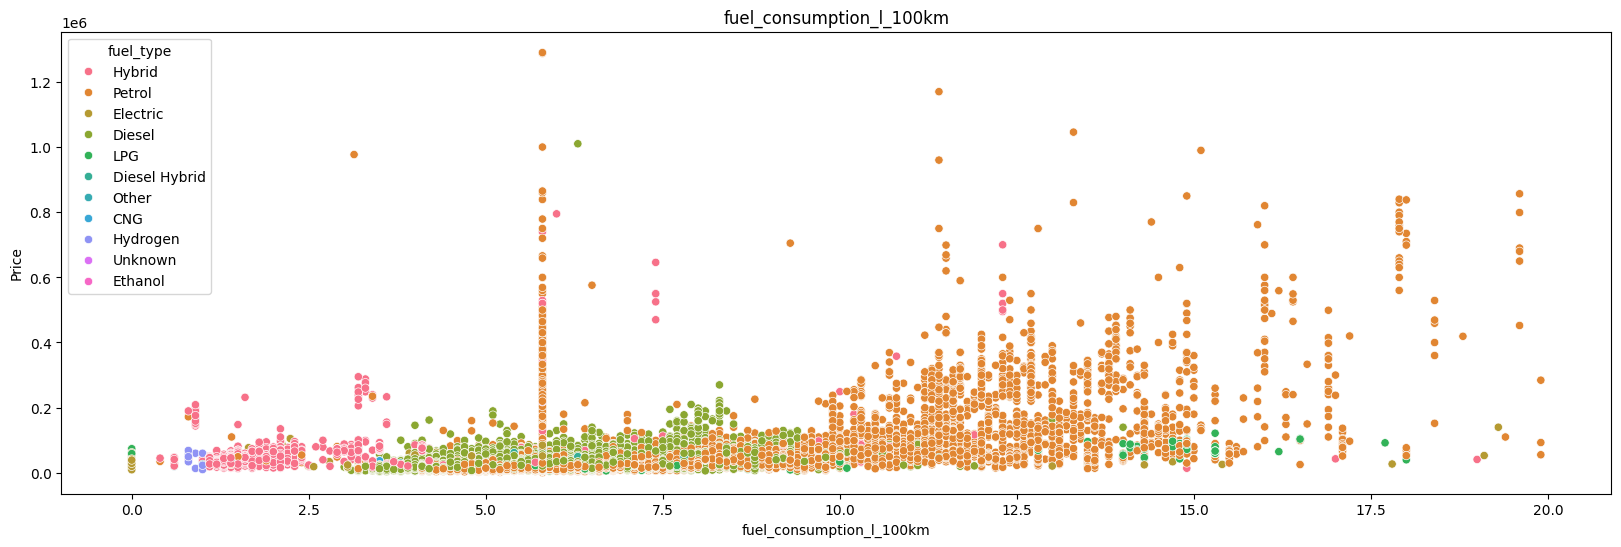

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(x=df['fuel_consumption_l_100km'],y=df['price_in_euro'],hue=df['fuel_type'])
plt.xlabel('fuel_consumption_l_100km')
plt.ylabel('Price')
plt.title('fuel_consumption_l_100km')
plt.show()

Insight:
* High-priced cars are mostly petrol, while diesel and other fuels appear in lower price ranges.

* Diesel cars are generally efficient, staying below ~10 L/100 km, while petrol extends up to ~20 L/100 km.

* The dataset is dominated by petrol cars (~53%).

CO2

In [ ]:
df.groupby('fuel_type')['fuel_consumption_g_km'].describe()

,count,mean,std,min,25%,50%,75%,max
fuel_type,,,,,,,,
CNG,47.0,128.978723,13.155408,96.0,121.0,137.0,139.0,147.0
Diesel,25073.0,144.487018,29.830928,90.0,124.0,139.0,158.0,250.0
Diesel Hybrid,137.0,137.138686,17.805808,96.0,130.0,139.0,148.0,180.0
Electric,2218.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Ethanol,1.0,139.000000,NaN,139.0,139.0,139.0,139.0,139.0
Hybrid,4242.0,119.826968,13.828718,80.0,120.0,120.0,120.0,180.0
Hydrogen,39.0,0.076923,0.269953,0.0,0.0,0.0,0.0,1.0
LPG,732.0,130.676230,12.361975,110.0,119.0,135.0,139.0,200.0
Other,77.0,138.077922,11.180065,100.0,139.0,139.0,139.0,189.0


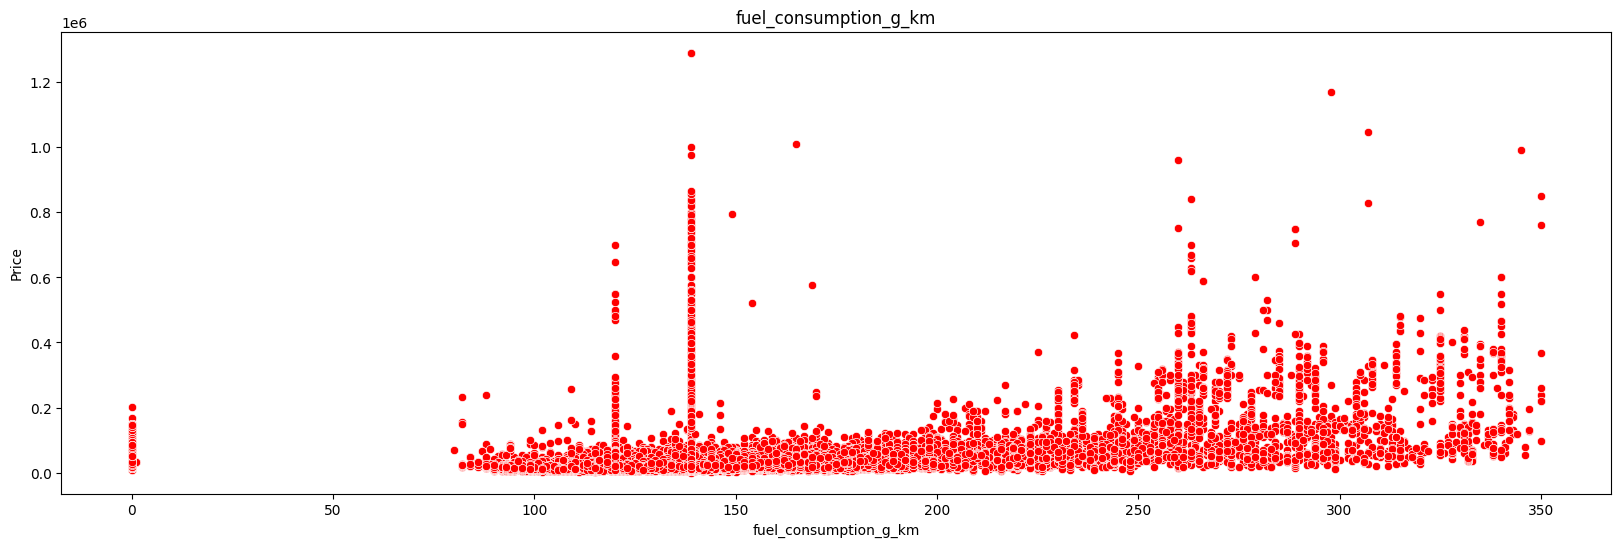

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(x=df['fuel_consumption_g_km'],y=df['price_in_euro'],color='red')
plt.xlabel('fuel_consumption_g_km')
plt.ylabel('Price')
plt.title('fuel_consumption_g_km')
plt.show()

Insight:
Electric and hydrogen cars have near-zero CO₂ emissions, showing a non-linear relationship with price and minimal impact on it. Overall, car price is influenced more by brand and features than by emissions.

CO2 Emission based on fuel type

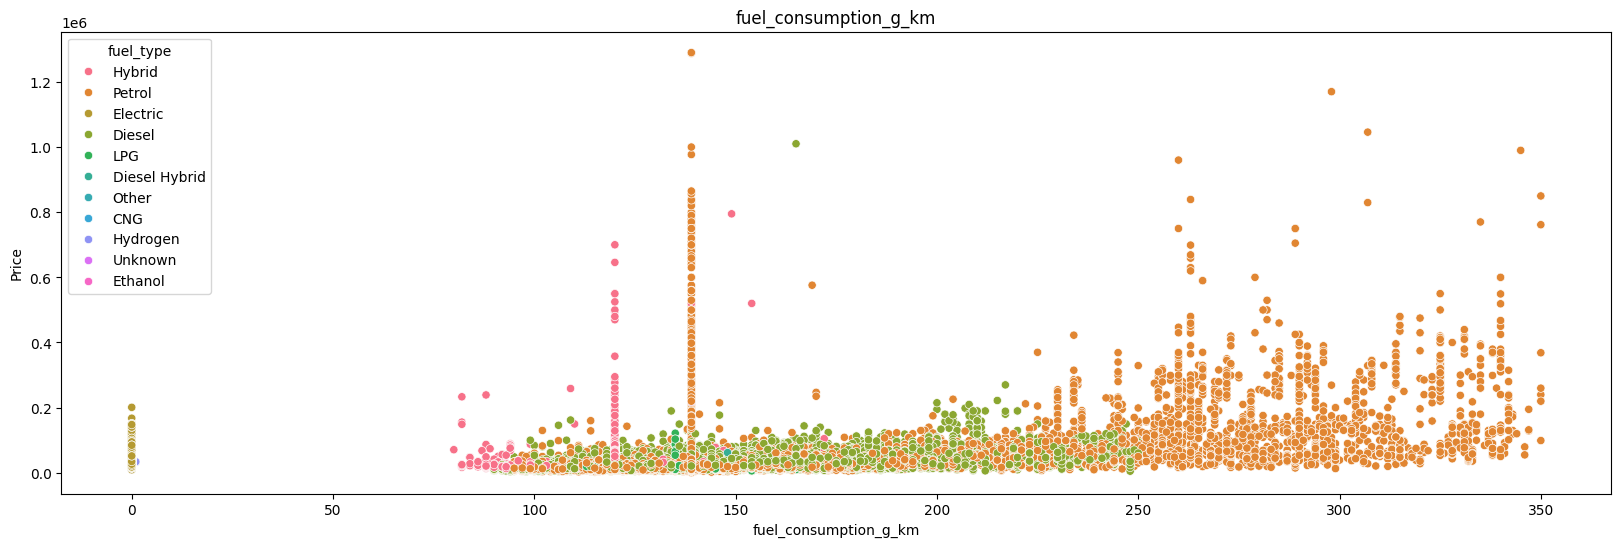

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(x=df['fuel_consumption_g_km'],y=df['price_in_euro'],hue=df['fuel_type'])
plt.xlabel('fuel_consumption_g_km')
plt.ylabel('Price')
plt.title('fuel_consumption_g_km')
plt.show()

Insight:
Electric and hydrogen cars have near-zero CO₂ emissions, while petrol and diesel cars emit more CO₂. Petrol cars are more frequent and include high-priced models, but for petrol and diesel, price is influenced more by brand and features than by emissions.

Power in ps

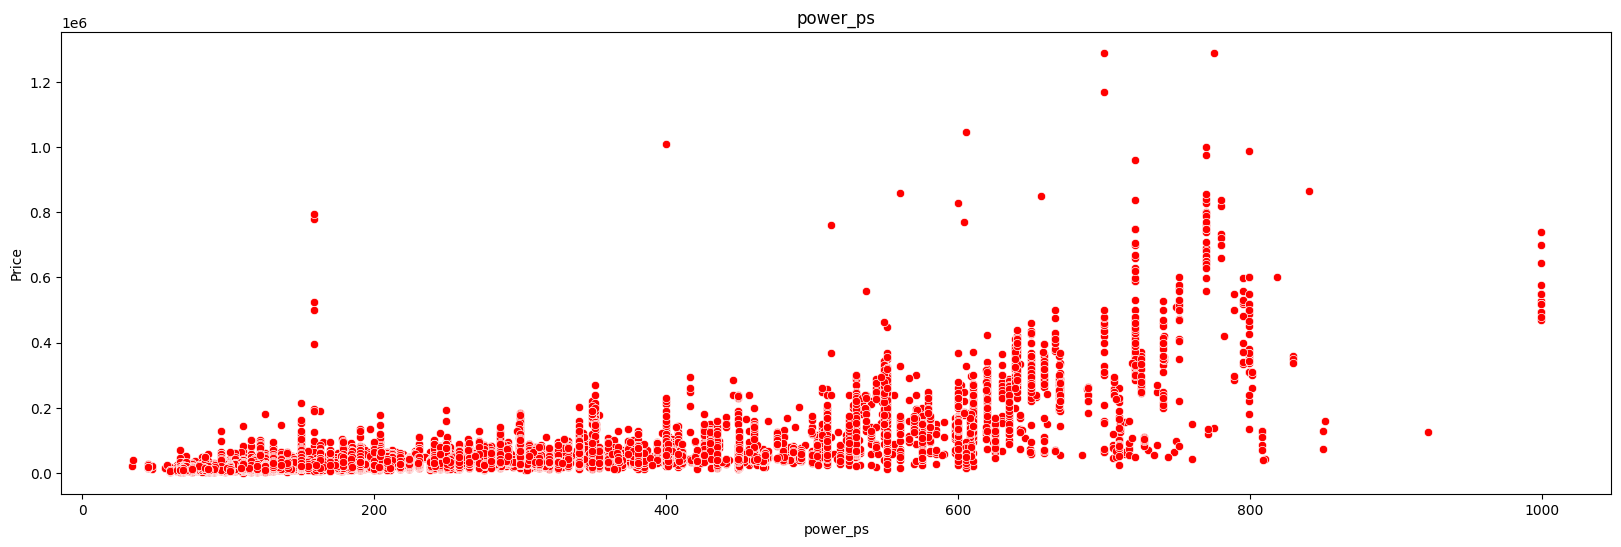

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(x=df['power_ps'],y=df['price_in_euro'],color='red')
plt.xlabel('power_ps')
plt.ylabel('Price')
plt.title('power_ps')
plt.show()

Insight:
* High power engines generally lead to higher prices since they are
associated with premium and luxury cars.
*  In some cases, even low-power cars can have a high price due to other influential factors such as brand value, luxury features, or design.

Power based on Brand


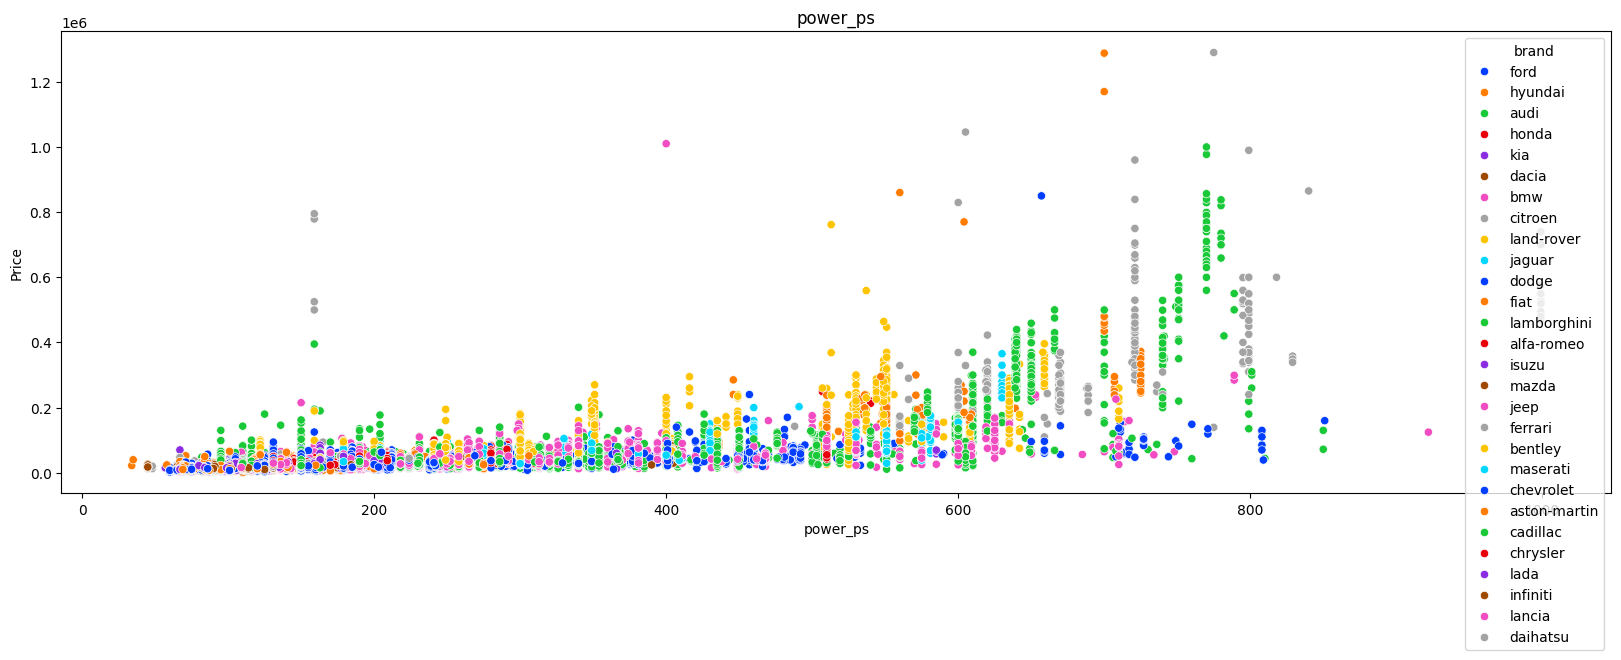

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(x=df['power_ps'],y=df['price_in_euro'],hue=df['brand'],palette='bright')
plt.xlabel('power_ps')
plt.ylabel('Price')
plt.title('power_ps')
plt.show()

Mileage

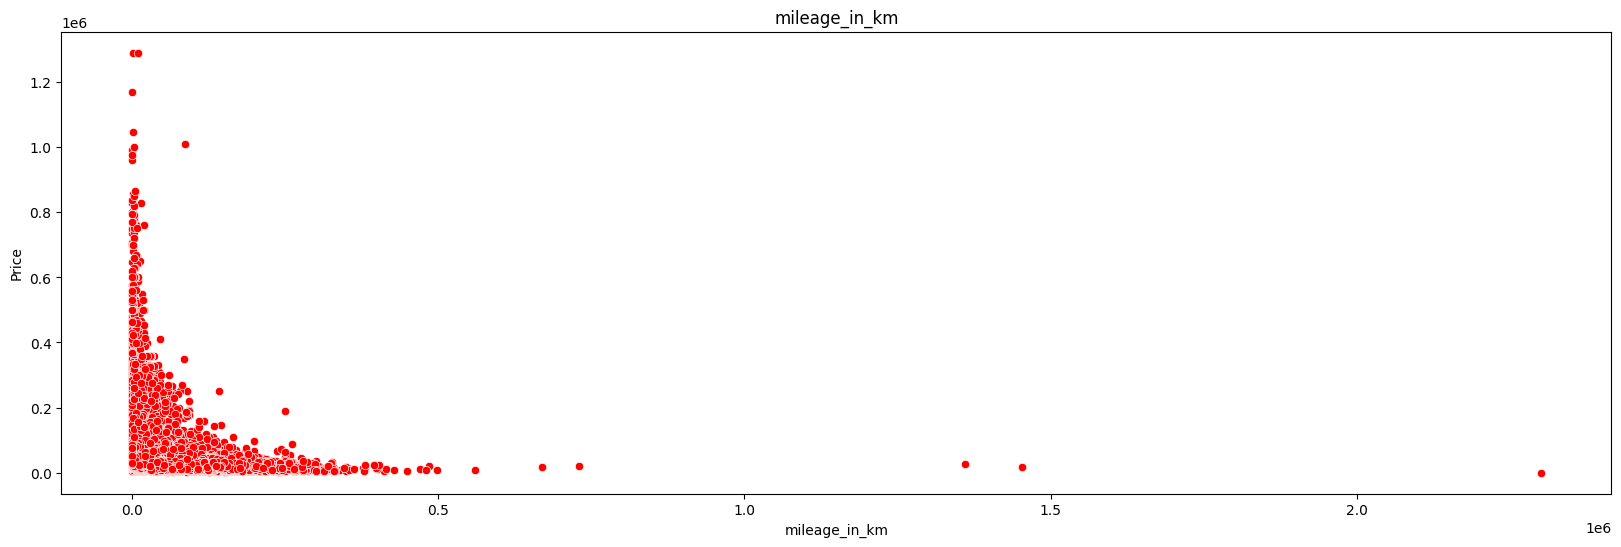

In [ ]:
plt.figure(figsize=(20,6))
sns.scatterplot(x=df['mileage_in_km'],y=df['price_in_euro'],color='red')
plt.xlabel('mileage_in_km')
plt.ylabel('Price')
plt.title('mileage_in_km')
plt.show()
#0.2*1e6 =200000

Insight:
* Negative correlation: Mileage and price show a clear negative relationship.

* Trend: Cars with low mileage are sold at higher prices, while high mileage cars are valued lower.

Correlation

<Axes: >

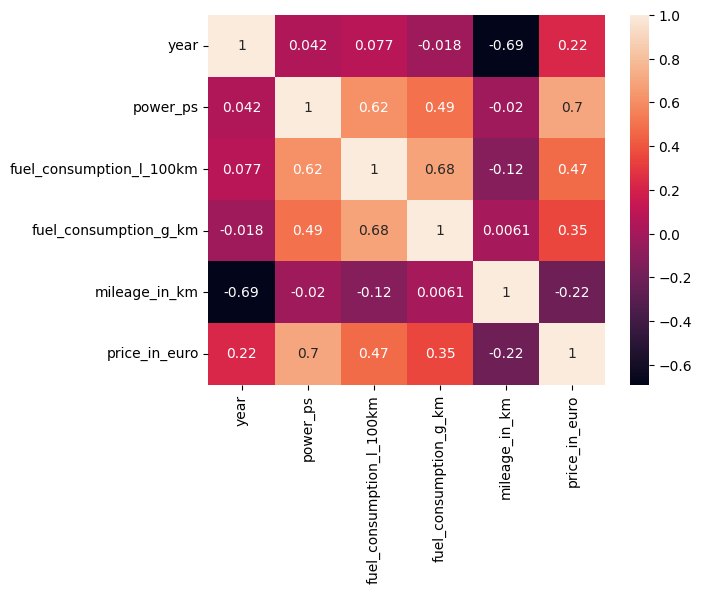

In [ ]:
#corr of numerical col by pearson corr(-1 to 1)
numerical_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numerical_cols].corr(),annot=True)

**Insight**:

Power:
* There is a strong positive linear relationship between engine power and price.

* Cars with higher power output are priced significantly higher.

Mileage:
* Negative correlation: Mileage and price show a clear negative relationship.

* Trend: Cars with low mileage are sold at higher prices, while high mileage cars are valued lower.

In [ ]:
#corr of categorical
categorical_features=['transmission_type','fuel_type','brand','color']
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['price_in_euro'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
print(result)

              Column       Hypothesis Result
0  transmission_type  Reject Null Hypothesis
1          fuel_type  Reject Null Hypothesis
2              brand  Reject Null Hypothesis
3              color  Reject Null Hypothesis


Insight:
* The Chi-Square test of independence shows that all categorical features
are significantly associated with car price.

* This means categorical variables impact the target and should be included in model building.

In [ ]:
#  top 5 brand's avg of high price cars
df.groupby('brand')['price_in_euro'].mean().sort_values(ascending=False).head()

,price_in_euro
brand,
lamborghini,377360.023810
ferrari,345167.798220
bentley,230181.683117
aston-martin,218986.075581
maserati,81206.652727


In [ ]:
#  top 5 transmission_type's avg of high price cars
df.groupby('transmission_type')['price_in_euro'].mean().sort_values(ascending=False).head()

,price_in_euro
transmission_type,
Semi-automatic,86843.338462
Unknown,46318.296875
Automatic,45739.746636
Manual,19385.090790


In [ ]:
#  top 5 fuel_type's avg of high price cars
df.groupby('fuel_type')['price_in_euro'].mean().sort_values(ascending=False)

,price_in_euro
fuel_type,
Unknown,50769.541667
Hydrogen,41484.692308
Electric,41479.233995
Diesel Hybrid,41454.430657
Hybrid,40224.670910
Petrol,36870.688680
Other,34416.233766
LPG,32389.508197
Diesel,31251.894548


In [ ]:
#  top 5 color's avg of high price cars
df.groupby('color')['price_in_euro'].mean().sort_values(ascending=False).head()

,price_in_euro
color,
green,62801.435563
violet,59261.028037
gold,58420.112500
yellow,57499.861582
bronze,40710.520661


In [ ]:
#  top 5 year's avg of high price cars
df.groupby('year')['price_in_euro'].mean().sort_values(ascending=False).head()

,price_in_euro
year,
2022,52996.240562
2023,47864.162107
2021,46348.344179
2020,39348.917816
2019,32363.906171


High mileage car details

In [ ]:
df.sort_values(by='mileage_in_km',ascending=False).head()

,brand,model,color,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
59576,fiat,Doblo,bronze,2022,110.0,Manual,Petrol,5.8,139.0,2300000.0,650.0
95326,ford,Galaxy,blue,2017,150.0,Automatic,Diesel,5.2,134.0,1453268.0,17500.0
51263,audi,Q5,black,2015,258.0,Automatic,Diesel,5.9,156.0,1360000.0,26500.0
80940,hyundai,TUCSON,black,2019,136.0,Automatic,Diesel,5.0,139.0,730500.0,20000.0
6943,audi,A3,silver,2017,116.0,Automatic,Diesel,5.8,139.0,670000.0,18000.0


Low mileage car details

In [ ]:
df.sort_values(by='mileage_in_km').head()

,brand,model,color,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
52777,ford,Transit,grey,2022,185.0,Manual,Diesel,5.9,154.0,0.0,59470.0
74543,fiat,500C,black,2023,69.0,Manual,Hybrid,4.1,94.0,0.0,20880.0
98608,fiat,Tipo,grey,2023,131.0,Automatic,Petrol,4.7,118.0,0.0,25890.0
63551,fiat,500,grey,2023,69.0,Manual,Petrol,4.1,139.0,0.0,15890.0
49483,citroen,C3,beige,2023,83.0,Manual,Petrol,4.2,97.0,0.0,17990.0


High Power car details

In [ ]:
df.sort_values(by='power_ps',ascending=False).head()

,brand,model,color,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
3335,ferrari,SF90 Stradale,red,2023,999.0,Automatic,Hybrid,12.3,120.0,95.0,549980.0
44589,ferrari,SF90 Stradale,red,2022,999.0,Automatic,Hybrid,12.3,154.0,80.0,520000.0
60124,ferrari,SF90 Spider,blue,2021,999.0,Automatic,Hybrid,12.3,120.0,2332.0,699980.0
68173,ferrari,SF90 Stradale,red,2021,999.0,Automatic,Hybrid,5.8,139.0,1300.0,520000.0
25392,ferrari,SF90 Stradale,black,2022,999.0,Automatic,Hybrid,7.4,120.0,4680.0,469900.0


High price car details

In [ ]:
df.sort_values(by='price_in_euro',ascending=False).head()

,brand,model,color,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,price_in_euro
41963,ferrari,F12,yellow,2017,775.0,Automatic,Petrol,5.8,139.0,10800.0,1290000.0
29570,aston-martin,Aston Martin Vantage,green,2022,700.0,Automatic,Petrol,5.8,139.0,1600.0,1288000.0
92908,aston-martin,Aston Martin Vantage,blue,2022,700.0,Automatic,Petrol,11.4,298.0,80.0,1170000.0
53356,ferrari,458,blue,2015,605.0,Automatic,Petrol,13.3,307.0,2824.0,1045800.0
68067,bmw,550,brown,2018,400.0,Automatic,Diesel,6.3,165.0,87000.0,1010101.0


Above 75 percentile data of price

In [ ]:
threshold = df['price_in_euro'].quantile(0.75)
_75 = df[df['price_in_euro'] >= threshold]


In [ ]:
x=['transmission_type','fuel_type','year','brand','color']
for i in x:
  print(_75[i].value_counts())

transmission_type
Automatic         16512
Manual              997
Unknown              83
Semi-automatic       15
Name: count, dtype: int64
fuel_type
Petrol           8146
Diesel           6410
Hybrid           1710
Electric          983
LPG               226
Diesel Hybrid      75
Other              28
Hydrogen           24
Unknown             4
CNG                 1
Name: count, dtype: int64
year
2023    3816
2022    3621
2019    2606
2020    2184
2021    1974
2018    1593
2017     893
2016     570
2015     350
Name: count, dtype: int64
brand
audi            4377
bmw             3089
land-rover      2191
ford            2007
jaguar           749
jeep             643
hyundai          608
alfa-romeo       559
dodge            527
maserati         509
kia              474
bentley          385
ferrari          337
lamborghini      294
citroen          183
aston-martin     172
chevrolet        116
isuzu             97
honda             88
fiat              87
cadillac          83
chrysler 

In [ ]:
df.to_csv('MODEL_DATA.csv',index=False)